# sourcing the data

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import math
import json

from plots.utils import load_sledge_data, prepare_step_data

plt.style.use("./plots/latex_style.mplstyle")

benches = ["ROVER", "Hydra", "Alive", "Cadence"]

RESULTS_DIR = Path("../results")
RESULTS_DIR_ALT = Path("../benchmarks/results")

FIGURES_PATH = RESULTS_DIR / "plots"

TIMEOUT = 60_000  # timeout in milliseconds

os.makedirs(FIGURES_PATH, exist_ok=True)

parabit = {}
mirabelle = {}
pbv = {}

pbv["Alive"] = pd.read_csv(f"{RESULTS_DIR_ALT}/solver/alive_smt2/results.csv")
pbv["Hydra"] = pd.read_csv(f"{RESULTS_DIR_ALT}/solver/hydra_smt2/results.csv")
pbv["Cadence"] = pd.read_csv(f"{RESULTS_DIR_ALT}/solver/Cadence_smt2/summary.csv")
pbv["ROVER"] = pd.read_csv(f"{RESULTS_DIR_ALT}/solver/rover_smt2/summary.csv")

for bench in benches:
    parabit[bench] = pd.read_csv(f"{RESULTS_DIR}/parabit/{bench}/results.csv")
    parabit[bench]["time_taken"] = (
        parabit[bench]["time_taken"] * 1000
    )  # convert seconds to milliseconds
    parabit[bench]["file"] = parabit[bench]["file"].str.replace(
        ".bwlang", "", regex=False
    )  # remove file extension
    if bench == "Hydra":
        parabit[bench]["file"] = parabit[bench]["file"].str.replace(
            "hydra_", "", regex=False
        )  # remove file extension
    parabit[bench].set_index("file")

    mirabelle[bench] = {}
    mirabelle[bench]["lemma"] = load_sledge_data(
        RESULTS_DIR / "mirabelle" / "lemma" / bench / "parsed.json"
    )
    mirabelle[bench]["nolemma"] = load_sledge_data(
        RESULTS_DIR / "mirabelle" / "nolemma" / bench / "parsed.json"
    )
    if bench == "Hydra":
        mirabelle[bench]["lemma"]["name"] = mirabelle[bench]["lemma"][
            "name"
        ].str.replace("hydra_", "", regex=False)  # remove file extension
        mirabelle[bench]["nolemma"]["name"] = mirabelle[bench]["nolemma"][
            "name"
        ].str.replace("hydra_", "", regex=False)  # remove file extension

    # remove problems that took longer than the timeout
    mirabelle[bench]["lemma"] = mirabelle[bench]["lemma"].where(
        mirabelle[bench]["lemma"]["time"] <= TIMEOUT
    )
    mirabelle[bench]["nolemma"] = mirabelle[bench]["nolemma"].where(
        mirabelle[bench]["nolemma"]["time"] <= TIMEOUT
    )
    mirabelle[bench]["lemma"].set_index("name")
    mirabelle[bench]["nolemma"].set_index("name")

    pbv[bench]["file"] = pbv[bench]["file"].str.replace(
        ".smt2", "", regex=False
    )  # remove file extension
    pbv[bench].set_index("file")

# pbv, parabit, mirabelle

In [2]:
def plot_cactus(ax, dataframe, timeout=None, pltopts=None):
    num_problems = len(dataframe)

    ax.axhline(
        num_problems,
        label=f"Number of problems: {num_problems}",
        color="black",
        linestyle="dotted",
    )
    if timeout:
        ax.axvline(
            timeout,
            label=f"Timeout: {timeout / 1000:.3g} Seconds",
            color="grey",
            linestyle="--",
        )

    solved_counts = []
    for name, values in dataframe.items():
        solved = values.dropna()
        x, y = prepare_step_data(solved.to_list())

        if timeout and x[-1] < timeout:
            y.append(y[-1])
            x.append(timeout)

        line_opts = pltopts.get(name, {}) if pltopts else {}

        ax.plot(
            x,
            y,
            drawstyle="steps-post",
            label=f"{name}: {len(solved)} (${100 * len(solved) / num_problems:.0f}\\%$) ",
            **line_opts,
        )
        solved_counts.append(len(solved))

    ax.set_xlabel("Runtime (ms)")
    ax.set_ylabel("Number of solved problems")
    ax.set_xscale("log")

    y_ticks = ax.get_yticks()
    y_ticks = [*y_ticks, num_problems] if num_problems not in y_ticks else y_ticks
    ax.set_yticks(sorted(y_ticks))

    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(sorted(set(solved_counts)))
    ax2.set_ylabel("Solved instances")


def plot_survival(ax, dataframe, timeout=None, pltopts=None):
    num_problems = len(dataframe)

    ax.axvline(num_problems, label=f"Number of problems: {num_problems}", color="blue")
    if timeout:
        ax.axhline(
            timeout,
            label=f"Timeout: {timeout / 1000:.3g} Seconds",
            color="grey",
            linestyle="--",
        )

    for name, values in dataframe.items():
        solved = values.dropna()
        y, x = prepare_step_data(solved.to_list())

        if timeout and x[-1] < num_problems:
            x.append(x[-1])
            y.append(timeout)

        line_opts = pltopts.get(name, {}) if pltopts else {}

        ax.plot(
            x,
            y,
            drawstyle="steps-post",
            label=f"{name}: {len(solved)} (${100 * len(solved) / num_problems:.0f}\\%$) ",
            **line_opts,
        )

    ax.set_ylabel("Runtime (ms)")
    ax.set_xlabel("Number of solved problems")
    ax.set_yscale("log")


def combine_results(x):
    vals_as_list = x.dropna().to_list()
    if vals_as_list != []:
        return min(x.dropna().to_list())
    else:
        return None


def get_parabit_times(df, index):
    return df[index]["time_taken"].where(df[index]["status"] == "SUCCESS")

In [3]:
datas = {}
for i, bench in enumerate(benches):
    all_names = (
        set(mirabelle[bench]["lemma"]["name"])
        | set(mirabelle[bench]["nolemma"]["name"])
        | set(parabit[bench]["file"])
        | set(pbv[bench]["file"])
    )

    data = pd.DataFrame()

    data["name"] = [x for x in all_names if type(x) is str]

    print(bench, len(data["name"]))

    if bench in ["Hydra", "Alive"]:
        filtered = pbv[bench][["time", "file"]].where(pbv[bench]["result"] == "unsat")
    else:
        filtered = pbv[bench][["unsat_time_average", "file"]].where(
            pbv[bench]["result"] == "unsat"
        )
        filtered = filtered.rename(columns={"unsat_time_average": "time"})

    filtered["time"] *= 1000  # convert second to ms
    data = data.merge(
        filtered[["time", "file"]], left_on="name", right_on="file", how="left"
    )
    data = data.rename(columns={"time": "pbv"}).drop(columns="file")

    filtered = parabit[bench][["time_taken", "file"]].where(
        parabit[bench]["status"] == "SUCCESS"
    )
    data = data.merge(
        filtered[["time_taken", "file"]], left_on="name", right_on="file", how="left"
    )
    data = data.rename(columns={"time_taken": "parabit"}).drop(columns="file")

    mir = mirabelle[bench]["lemma"]
    filtered = mir[["time", "name"]].where(mir["timeout"] == False)
    data = data.merge(
        filtered[["time", "name"]], left_on="name", right_on="name", how="left"
    )
    data = data.rename(columns={"time": "lemma"})

    mir = mirabelle[bench]["nolemma"]
    filtered = mir[["time", "name"]].where(mir["timeout"] == False)
    data = data.merge(
        filtered[["time", "name"]], left_on="name", right_on="name", how="left"
    )
    data = data.rename(columns={"time": "nolemma"})

    # mir = mirabelle[bench]['nolemma'].set_index('name')
    # data['nolemma'] = mir['time'].where(mir['timeout'] == False)
    datas[bench] = data

# datas

ROVER 29
Hydra 154
Alive 200
Cadence 5


In [9]:
from IPython.display import Markdown


def print_ifnotzero(input, name):
    if (l := len(input)) > 0:
        print(f"{l} ({l / total:%}) Problems uniquely solved by {name}:")
        pd.set_option("display.max_colwidth", None)
        display(input.rename(columns={name: "time (ms)"}))


display(Markdown("## Find unique solutions"))

unique_proofs = []

for bench in benches:
    print(f"*** {bench} ***")
    df = datas[bench]
    total = len(df)

    unsolved = df[
        df["pbv"].isna()
        & df["lemma"].isna()
        & df["nolemma"].isna()
        & df["parabit"].isna()
    ]
    print_ifnotzero(unsolved, 'none')

    parabit_unique = df[
        df["pbv"].isna()
        & df["lemma"].isna()
        & df["nolemma"].isna()
        & df["parabit"].notna()
    ]

    print_ifnotzero(parabit_unique[["name", "parabit"]], "parabit")

    lemma_unique = df[
        df["pbv"].isna()
        & df["parabit"].isna()
        & df["nolemma"].isna()
        & df["lemma"].notna()
    ]

    lemma_unique = lemma_unique.merge(
        mirabelle[bench]["lemma"][["proof", "name"]],
        left_on="name",
        right_on="name",
        how="left",
    )

    if len(lemma_unique) > 0:
        unique_proofs.append(lemma_unique[["name", "proof"]].to_dict())

    print_ifnotzero(lemma_unique[["name", "lemma", "proof"]], "lemma")

    nolemma_unique = df[
        df["pbv"].isna()
        & df["parabit"].isna()
        & df["lemma"].isna()
        & df["nolemma"].notna()
    ]
    print_ifnotzero(nolemma_unique[["name", "nolemma"]], "nolemma_unique")

    pbv_unique = df[
        df["parabit"].isna()
        & df["lemma"].isna()
        & df["nolemma"].isna()
        & df["pbv"].notna()
    ]
    print_ifnotzero(pbv_unique[["name", "pbv"]], "pbv_unique")


## Find unique solutions

*** ROVER ***
1 (3.448276%) Problems uniquely solved by none:


,name,pbv,parabit,lemma,nolemma
21,redundant_sel_add,NaN,NaN,NaN,NaN


10 (34.482759%) Problems uniquely solved by parabit:


,name,time (ms)
0,mult_assoc_1,2.856880
1,mult_sum_same,16.408905
5,left_shift_mult,2.482286
6,left_shift_add_2,4.262557
18,dist_over_add,4.459686
20,add_right_shift,5.408236
24,merge_left_shift,4.684791
25,move_sel_zero,15.048446
27,merge_right_shift,3.649066
28,left_shift_add_1,4.216081


...

,name,pbv
0,AndOrXor_924_values_0,38556.638479
1,AndOrXor_1844_values_0,12.460947
6,AndOrXor_966_values_0,14.607430
9,AndOrXor_1683_2_values_0,15.377045
14,AndOrXor_941_values_0,14.810562
...,...,...
189,AndOrXor_1850_values_0,7.793188
191,AndOrXor_931_values_0,46.818733
192,AndOrXor_151_values_0,203.001022
196,AndOrXor_961_values_0,21.178961


*** Cadence ***
3 (60.000000%) Problems uniquely solved by parabit:


,name,time (ms)
0,equation_abc,531.004670
2,unsigned_rounding_v0_to_v2,489.452943
3,unsigned_rounding_v1_to_v2,459.108391


1 (20.000000%) Problems uniquely solved by pbv_unique:


,name,pbv
1,abs_diff_shared_sub_signed,708.2


In [8]:
from IPython.display import Markdown

display(Markdown("## Only compare parabit to slegehammer (with lemmas)"))

for bench in benches:
    print(f"*** {bench} ***")
    df = datas[bench].drop(columns="pbv")
    total = len(df)

    unsolved = df[df["lemma"].isna() & df["parabit"].isna()]
    print_ifnotzero(unsolved, 'none')

    parabit_unique = df[df["lemma"].isna() & df["parabit"].notna()]

    print_ifnotzero(parabit_unique[["name", "parabit"]], "parabit")

    lemma_unique = df[df["parabit"].isna() & df["lemma"].notna()]

    lemma_unique = lemma_unique.merge(
        mirabelle[bench]["lemma"][["proof", "name"]],
        left_on="name",
        right_on="name",
        how="left",
    )
    if len(lemma_unique) > 0:
        unique_proofs.append(lemma_unique[["name", "proof"]].to_dict())

    print_ifnotzero(lemma_unique[["name", "lemma", "proof"]], "lemma")

## Only compare parabit to slegehammer (with lemmas)

*** ROVER ***
2 (6.896552%) Problems uniquely solved by none:


,name,parabit,lemma,nolemma
3,redundant_sel,NaN,NaN,NaN
21,redundant_sel_add,NaN,NaN,NaN


14 (48.275862%) Problems uniquely solved by parabit:


,name,time (ms)
0,mult_assoc_1,2.856880
1,mult_sum_same,16.408905
5,left_shift_mult,2.482286
6,left_shift_add_2,4.262557
7,mul_two,1.381267
15,sel_add,615.808281
17,sel_add_zero,563.795017
18,dist_over_add,4.459686
20,add_right_shift,5.408236
22,sum_same,1.364342


...

,name,time (ms),proof
0,AndOrXor_2475_values_0,6711.0,by (metis Groups.add_0 add.commute bit.xor_compl_left bw_0 mod_prop_sub_left mod_prop_sum mod_prop_xor not_add_distrib not_diff_distrib xor.commute xor.left_neutral) (2.0 s)


*** Cadence ***
1 (20.000000%) Problems uniquely solved by none:


,name,parabit,lemma,nolemma
1,abs_diff_shared_sub_signed,NaN,NaN,NaN


4 (80.000000%) Problems uniquely solved by parabit:


,name,time (ms)
0,equation_abc,531.004670
2,unsigned_rounding_v0_to_v2,489.452943
3,unsigned_rounding_v1_to_v2,459.108391
4,abs_diff_shared_sub,501.800567


In [6]:

new_dict = {}

for proof in unique_proofs:
    for name, proof in zip(proof["name"].values(), proof["proof"].values()):
        new_dict[name] = proof

new_dict

axiom_list = [
    "add_0",
    "add_as_xor_and",
    "add_eq_prec",
    "add_full_prec",
    "add_remove_prec_left",
    "add_remove_prec_right",
    "and_allones",
    "and_assoc",
    "and_distrib",
    "and_not_self",
    "and_one",
    "and_remove",
    "and_remove_inner",
    "and_self",
    "and_zero",
    "bw_0",
    "bw_1",
    "bw_max_val",
    "bw_pow_sum",
    "bw_subset",
    "demorg_and",
    "demorg_or",
    "diff_left_eq_prec",
    "diff_left_remove_prec",
    "diff_right_eq_prec",
    "diff_right_remove_prec",
    "diff_self",
    "div_1",
    "div_by_more",
    "div_div_simp",
    "div_floor",
    "div_floor_help",
    "div_gte",
    "div_mult_self",
    "div_pow_join",
    "div_same",
    "int_distrib",
    "mod_eq",
    "mod_prop_and",
    "mod_prop_mod",
    "mod_prop_mul",
    "mod_prop_neg",
    "mod_prop_not",
    "mod_prop_or",
    "mod_prop_sub_left",
    "mod_prop_sub_right",
    "mod_prop_sum",
    "mod_prop_xor",
    "mul_by_bit",
    "mul_by_bit_eq",
    "mul_eq_prec",
    "mul_full_prec",
    "mul_pow2",
    "mul_remove_prec",
    "mult_0",
    "mult_1",
    "mult_2",
    "neg_not",
    "not_0_allones",
    "not_bw_not",
    "or_allones",
    "or_assoc",
    "or_not_self",
    "or_remove",
    "or_remove_inner",
    "or_self",
    "or_zero",
    "prop_two",
    "reduce_mod",
    "reduce_mod_bis",
    "redundant_signed",
    "shift_mod",
    "shr_by_pos",
    "signed_of_diff",
    "signed_of_neg",
    "signed_zext",
    "sub_to_neg",
    "unused_generic_or_simpl",
    "xor_allones",
    "xor_and_or",
    "xor_and_or_help",
    "xor_as_or_and",
    "xor_one",
    "xor_remove",
    "xor_remove_inner",
]

for name, proof in new_dict.items():
    str_out = proof
    for axiom in axiom_list:
        str_out = str_out.replace(axiom, '')
    print(f"{name}: {str_out}")

display(Markdown("---"))
print("missing xor.commute and xor.assoc, present in:\n")
print([name for name, proof in new_dict.items() if 'xor' in proof])
for name, arr in [(name, [x for x in proof.split(' ') if 'xor' in x]) for name, proof in new_dict.items() if 'xor' in proof]:
    print(name, arr)
display(Markdown("---"))
print("opt 724 is a fundamental bitwise identity: a & (a | b) = a")

opt_724: by (metis or.left_idem    or.left_commute bit.disj_conj_distrib2 zero_and_eq bit.disj_zero_right of_int_0_le_iff zero_less_double_add_iff_zero_less_single_add of_int_0_less_iff) (77 ms)
AndOrXor_2475_values_0: by (metis Groups. add.commute bit.xor_compl_left     not_add_distrib not_diff_distrib xor.commute xor.left_neutral) (2.0 s)


---

missing xor.commute and xor.assoc, present in:

['AndOrXor_2475_values_0']
AndOrXor_2475_values_0 ['bit.xor_compl_left', 'mod_prop_xor', 'xor.commute', 'xor.left_neutral)']


---

opt 724 is a fundamental bitwise identity: a & (a | b) = a


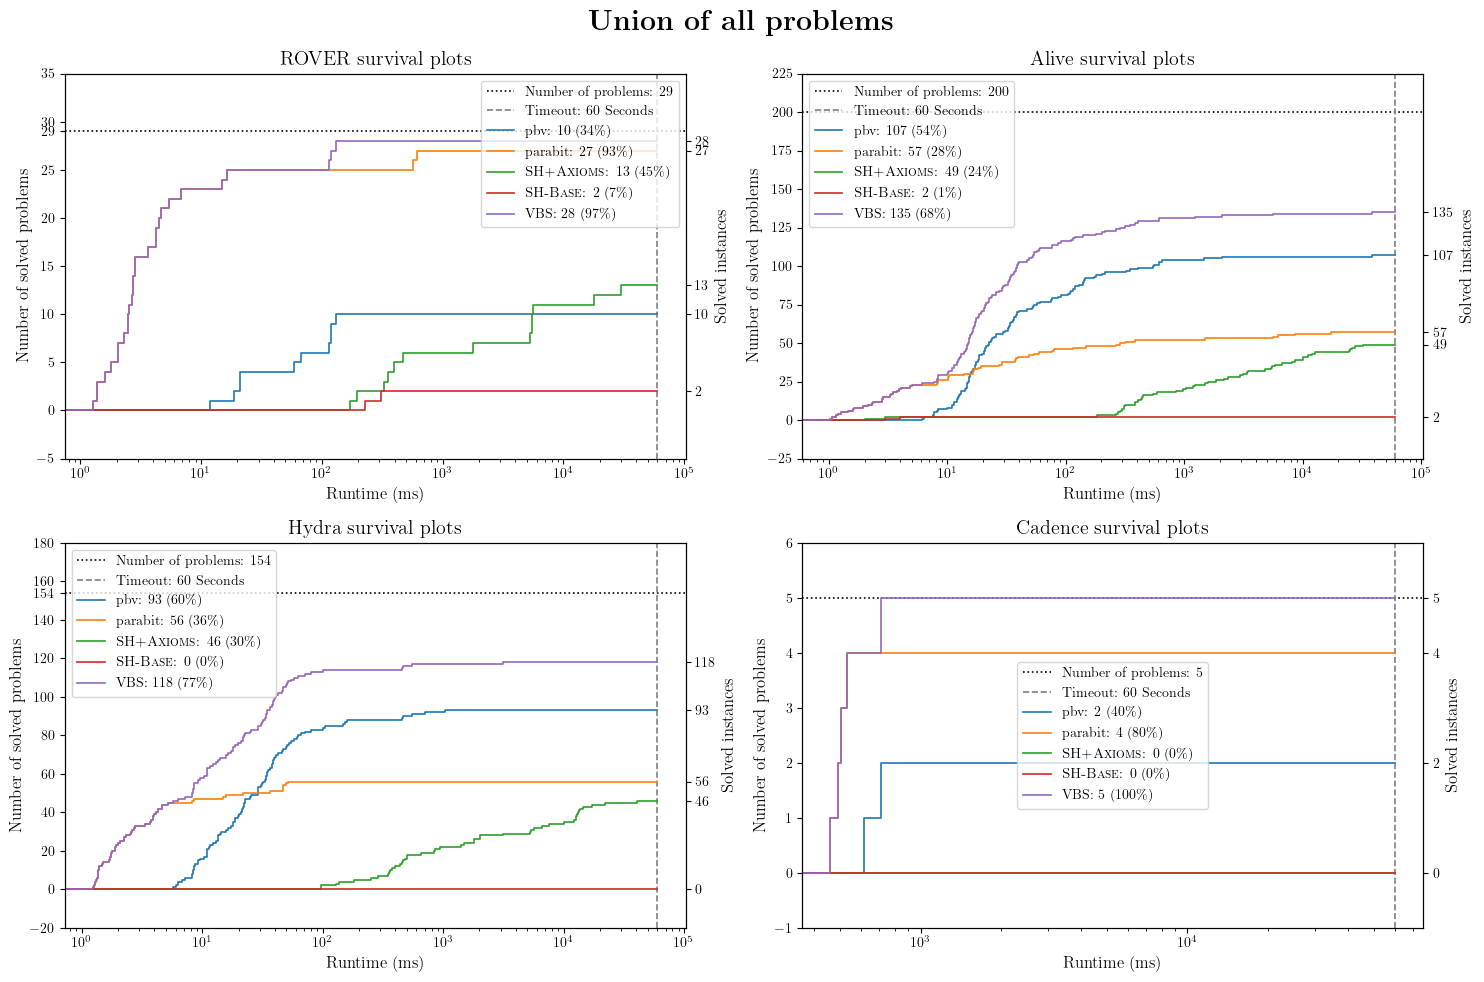

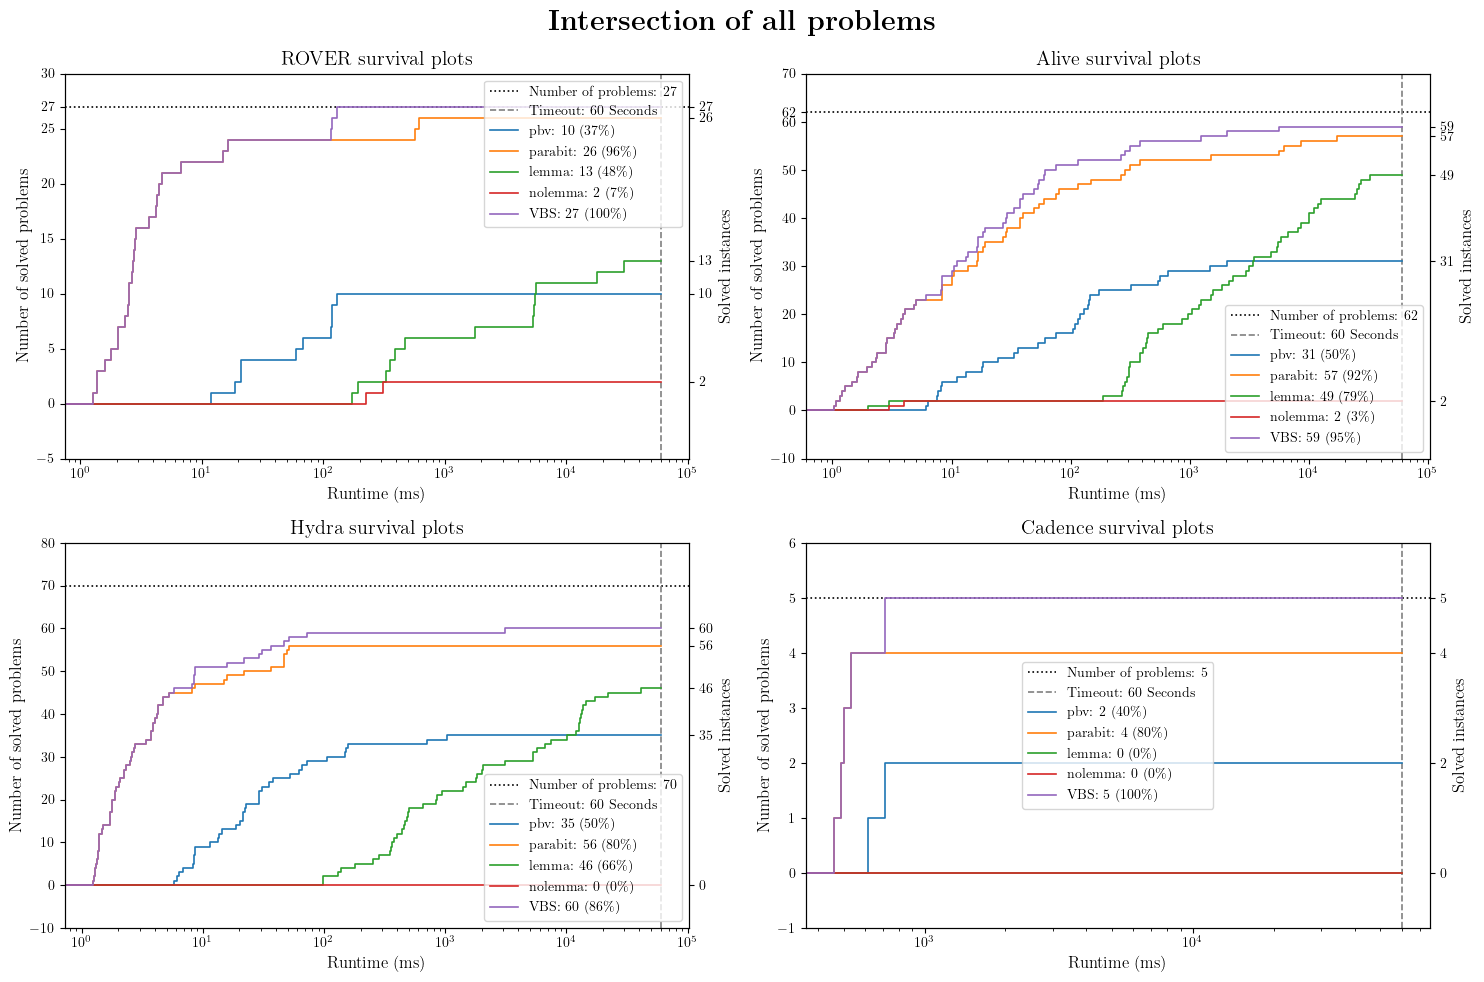

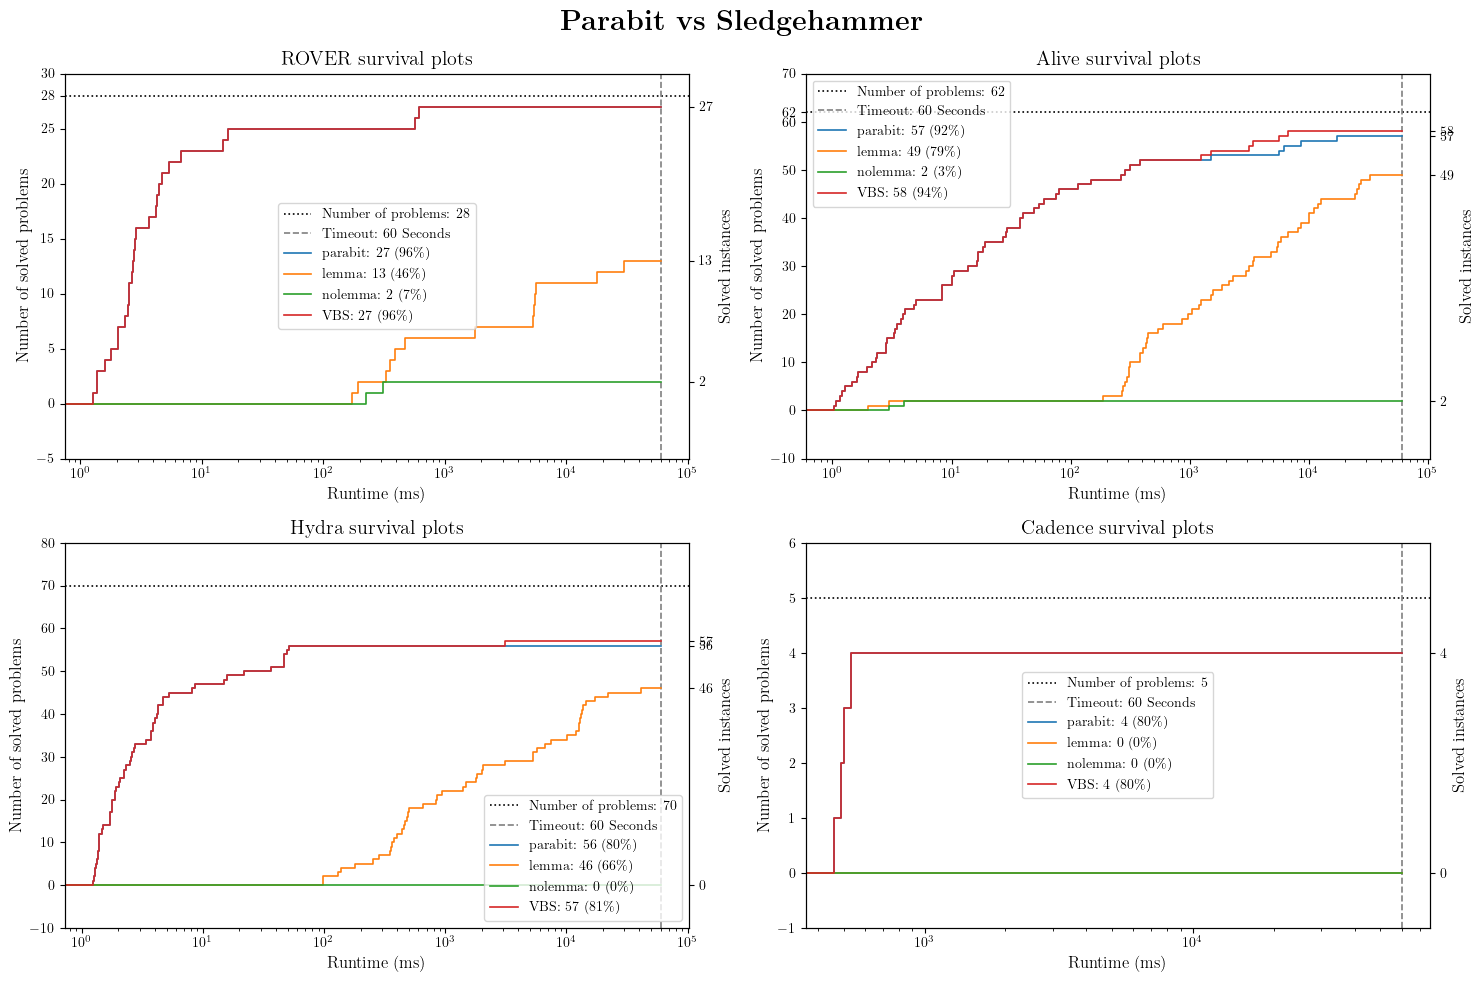

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
for i, (bench, data) in enumerate(datas.items()):
    ax = axs[i % 2][i // 2]
    data_tmp = data.copy().drop(columns="name")
    data_tmp["VBS"] = data_tmp[["pbv", "lemma", "nolemma", "parabit"]].apply(
        combine_results, axis=1
    )
    data_tmp = data_tmp.rename(
        columns={"lemma": "\\textsc{SH+Axioms}", "nolemma": "\\textsc{SH-Base}"}
    )

    plot_cactus(ax, data_tmp, TIMEOUT)
    ax.legend(loc="best")
    ax.set_title(f"{bench} survival plots")
fig.suptitle("\\textbf{Union of all problems}", fontsize="xx-large")
plt.tight_layout()
# plt.savefig(f"{FIGURES_PATH}all_problem.pdf")
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
for i, (bench, data) in enumerate(datas.items()):
    data_tmp = data.copy()

    filter_frame = data_tmp["name"].isin(parabit[bench]["file"]) & data_tmp[
        "name"
    ].isin(pbv[bench]["file"])
    data_tmp = data_tmp[filter_frame].drop(columns="name")
    data_tmp["VBS"] = data_tmp[["pbv", "lemma", "nolemma", "parabit"]].apply(
        combine_results, axis=1
    )

    ax = axs[i % 2][i // 2]
    plot_cactus(ax, data_tmp, TIMEOUT)
    ax.legend(loc="best")
    ax.set_title(f"{bench} survival plots")
fig.suptitle("\\textbf{Intersection of all problems}", fontsize="xx-large")
plt.tight_layout()
# plt.savefig(f"{FIGURES_PATH}all_problem.pdf")
plt.show()


fig, axs = plt.subplots(2, 2, figsize=(15, 10))
for i, (bench, data) in enumerate(datas.items()):
    data_tmp = data.copy()

    filter_frame = data_tmp["name"].isin(parabit[bench]["file"])
    data_tmp = data_tmp[filter_frame].drop(columns=["name", "pbv"])

    data_tmp["VBS"] = data_tmp[["lemma", "nolemma", "parabit"]].apply(
        combine_results, axis=1
    )

    ax = axs[i % 2][i // 2]
    plot_cactus(ax, data_tmp, TIMEOUT)
    ax.legend(loc="best")
    ax.set_title(f"{bench} survival plots")
fig.suptitle("\\textbf{Parabit vs Sledgehammer}", fontsize="xx-large")
plt.tight_layout()
# plt.savefig(f"{FIGURES_PATH}all_problem.pdf")
plt.show()
